# How SVM Kernels Affect Breast Cancer Classification

**Author:** Samia Arif  
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset  
**GitHub:** https://github.com/YOUR_USERNAME/breast-cancer-svm-tutorial

---

## Introduction

Support Vector Machines (SVM) are powerful supervised learning models used for classification tasks. The core idea behind SVM is to find the **optimal hyperplane** that best separates two classes — in our case, **malignant** (cancerous) and **benign** (non-cancerous) tumours.

What makes SVM particularly flexible is the **kernel trick**: by mapping data into a higher-dimensional space, SVM can separate classes that are not linearly separable in the original feature space.

### What This Tutorial Covers

This tutorial investigates:
1. How three different SVM kernels (`linear`, `poly`, `rbf`) affect classification performance
2. How the regularisation parameter `C` controls the bias-variance trade-off
3. Visualisation of decision boundaries using PCA
4. Cross-validation to ensure robust results

### Dataset

The Breast Cancer Wisconsin dataset contains **569 samples** and **30 numerical features** (e.g. radius, texture, smoothness of cell nuclei), with a binary target: `1 = malignant`, `0 = benign`.

> **References:**  
> - Cortes, C. & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273–297.  
> - Wolberg, W.H. et al. (1995). Breast Cancer Wisconsin (Diagnostic) Dataset. UCI Machine Learning Repository.  
> - Scikit-learn documentation: https://scikit-learn.org/stable/modules/svm.html

## Step 1: Import Libraries

We use `pandas` and `numpy` for data handling, `scikit-learn` for machine learning, and `matplotlib`/`seaborn` for visualisation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2: Load and Explore the Dataset

The dataset is loaded from the CSV file included in this repository. It contains 30 features describing cell nucleus characteristics, computed from digitised images of fine needle aspirate (FNA) of breast masses.

The `target` column is our label: `1 = malignant`, `0 = benign`.

In [4]:
# Load dataset — ensure breast_cancer_dataset.csv is in the same folder as this notebook
data = pd.read_csv('breast_cancer_dataset.csv')

print(f"Dataset shape: {data.shape}")
print(f"\nClass distribution:")
print(data['target'].value_counts().rename({1: 'Malignant', 0: 'Benign'}))
data.head()

Dataset shape: (569, 31)

Class distribution:
target
Malignant    357
Benign       212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum().sum(), "total missing values")

# Basic statistics
data.describe().round(2)

Missing values per column:
0 total missing values


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


## Step 3: Preprocessing

SVM is sensitive to the scale of features. We must **standardise** the data so that features with large values (e.g. area ~1000) do not dominate features with small values (e.g. smoothness ~0.1).

We use `StandardScaler`, which transforms each feature to have **mean = 0** and **standard deviation = 1**.

> ⚠️ Important: We fit the scaler **only on training data**, then apply it to test data. This prevents **data leakage**.

In [6]:
# Separate features and target
X = data.drop('target', axis=1)
y = data['target']

# Train-test split (70% train, 30% test), stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler — no re-fitting!

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")

Training samples: 398
Test samples:     171


## Step 4: Kernel Comparison — The Core Experiment

SVM kernels determine how the algorithm maps data to a higher-dimensional space:

| Kernel | Description | Best When |
|--------|-------------|----------|
| **Linear** | Straight hyperplane | Data is linearly separable |
| **Polynomial (poly)** | Curved boundary using polynomial functions | Moderate non-linearity |
| **RBF (Radial Basis Function)** | Gaussian bell-shaped boundary | Complex, non-linear data |

We also vary the **C parameter** (regularisation):
- **Low C** → wider margin, more misclassifications allowed → less overfitting
- **High C** → narrow margin, fewer misclassifications → risk of overfitting

In [7]:
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for C in C_values:
        model = SVC(kernel=kernel, C=C, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        results.append({'Kernel': kernel, 'C': C, 'Accuracy': acc})
        print(f"Kernel={kernel:8s}, C={C:4} => Accuracy={acc:.4f}")

results_df = pd.DataFrame(results)

Kernel=linear  , C= 0.1 => Accuracy=0.9708
Kernel=linear  , C=   1 => Accuracy=0.9825
Kernel=linear  , C=  10 => Accuracy=0.9532
Kernel=poly    , C= 0.1 => Accuracy=0.8363
Kernel=poly    , C=   1 => Accuracy=0.8947
Kernel=poly    , C=  10 => Accuracy=0.9532
Kernel=rbf     , C= 0.1 => Accuracy=0.9357
Kernel=rbf     , C=   1 => Accuracy=0.9766
Kernel=rbf     , C=  10 => Accuracy=0.9766


## Step 5: Visualise Kernel and C Performance

The bar chart below allows us to directly compare how each kernel performs across different C values. This is the key figure of our tutorial — it shows at a glance which kernel-C combination is most effective.

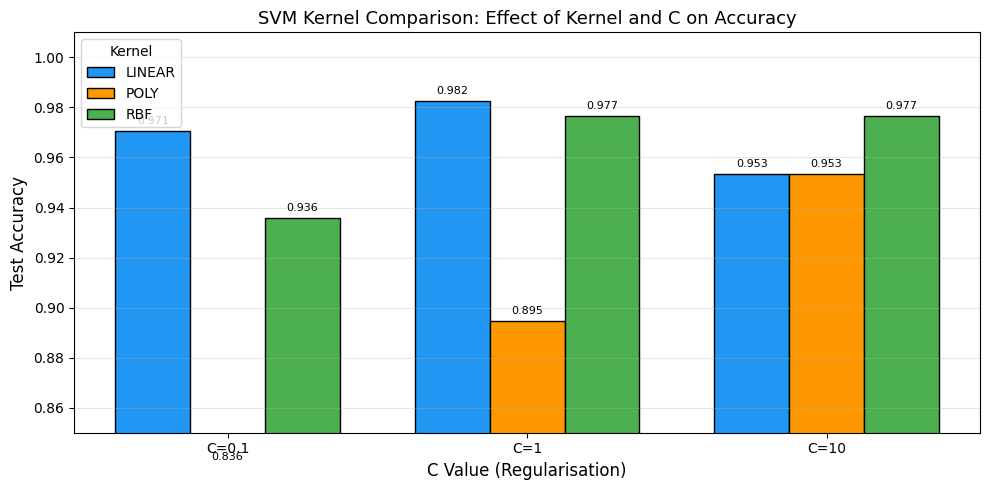

Figure saved as kernel_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(C_values))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']  # colorblind-safe palette

for i, kernel in enumerate(kernels):
    subset = results_df[results_df['Kernel'] == kernel]
    bars = ax.bar(x + i * width, subset['Accuracy'], width,
                  label=kernel.upper(), color=colors[i], edgecolor='black')
    # Add value labels on bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('C Value (Regularisation)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('SVM Kernel Comparison: Effect of Kernel and C on Accuracy', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels([f'C={c}' for c in C_values])
ax.set_ylim(0.85, 1.01)
ax.legend(title='Kernel')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as kernel_comparison.png")

## Step 6: Cross-Validation for Robust Evaluation

A single train/test split can be misleading depending on which samples end up in which split. **5-fold cross-validation** divides the data into 5 equal parts, trains on 4 and tests on 1, repeating 5 times. This gives a more reliable accuracy estimate.

We run cross-validation on the best-performing configurations.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("5-Fold Cross-Validation Results:")
print("-" * 45)

cv_results = []
for kernel in kernels:
    for C in C_values:
        # Use a pipeline to prevent data leakage during cross-validation
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel=kernel, C=C, random_state=42))
        ])
        scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
        cv_results.append({
            'Kernel': kernel, 'C': C,
            'CV Mean': scores.mean(),
            'CV Std': scores.std()
        })
        print(f"Kernel={kernel:8s}, C={C:4} => CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)
best = cv_df.loc[cv_df['CV Mean'].idxmax()]
print(f"\n✅ Best configuration: Kernel={best['Kernel']}, C={best['C']}, CV Accuracy={best['CV Mean']:.4f}")

5-Fold Cross-Validation Results:
---------------------------------------------
Kernel=linear  , C= 0.1 => CV Accuracy: 0.9737 ± 0.0055
Kernel=linear  , C=   1 => CV Accuracy: 0.9719 ± 0.0086
Kernel=linear  , C=  10 => CV Accuracy: 0.9684 ± 0.0131
Kernel=poly    , C= 0.1 => CV Accuracy: 0.8384 ± 0.0333
Kernel=poly    , C=   1 => CV Accuracy: 0.9034 ± 0.0227
Kernel=poly    , C=  10 => CV Accuracy: 0.9614 ± 0.0296
Kernel=rbf     , C= 0.1 => CV Accuracy: 0.9455 ± 0.0170
Kernel=rbf     , C=   1 => CV Accuracy: 0.9736 ± 0.0147
Kernel=rbf     , C=  10 => CV Accuracy: 0.9772 ± 0.0089

✅ Best configuration: Kernel=rbf, C=10.0, CV Accuracy=0.9772


## Step 7: Detailed Evaluation of Best Model

We now evaluate the best-performing model in detail using:
- **Confusion Matrix**: Shows true positives, false positives, true negatives, false negatives
- **Classification Report**: Precision, recall, and F1-score per class

In medical diagnosis, **recall for malignant cases** is especially important — a false negative (missing a cancer) is far more dangerous than a false positive.

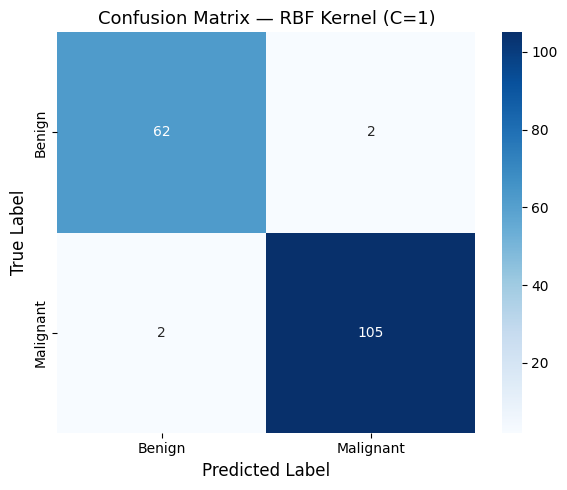


Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        64
   Malignant       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [10]:
# Train best model (RBF, C=1 — adjust if your results differ)
best_model = SVC(kernel='rbf', C=1, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — RBF Kernel (C=1)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

## Step 8: Decision Boundary Visualisation with PCA

Since our dataset has 30 features, we cannot plot the decision boundary directly. We use **PCA (Principal Component Analysis)** to reduce the data to 2 dimensions, then visualise the SVM decision boundary in this 2D space.

The plot below shows side-by-side decision boundaries for all three kernels, allowing us to see how each one carves up the feature space differently.

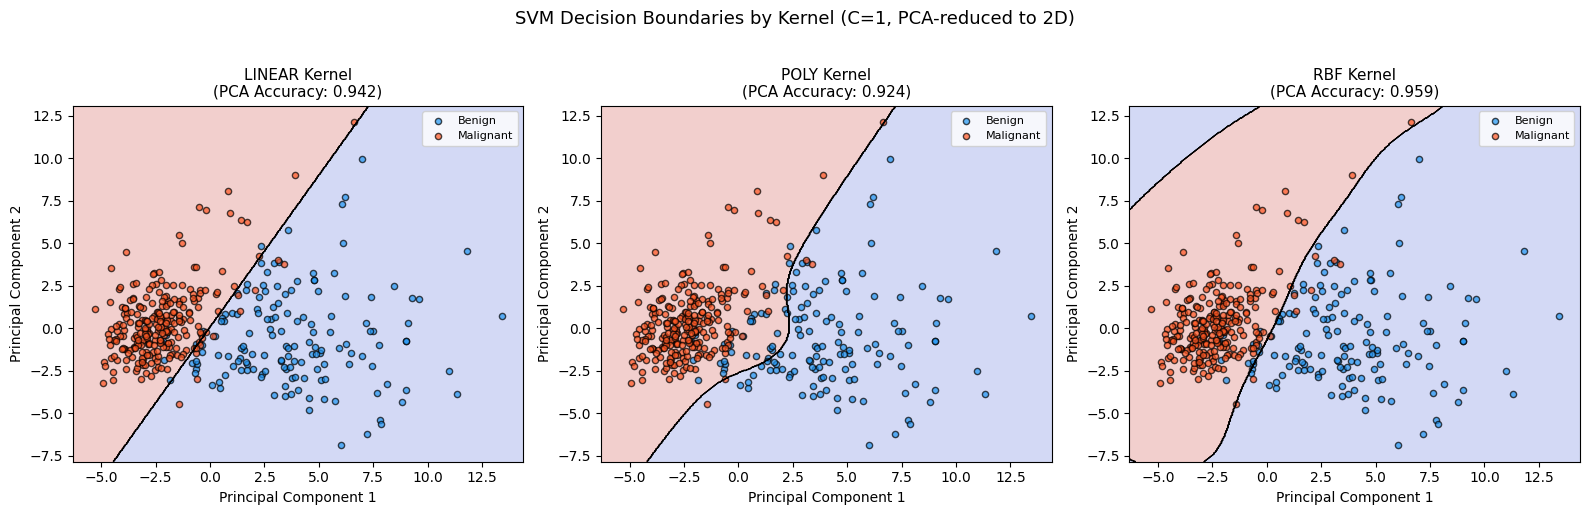

Figure saved as decision_boundaries.png


In [11]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create mesh grid for boundary plotting
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_scatter = ['#2196F3', '#FF5722']  # Blue=Benign, Orange=Malignant

for ax, kernel in zip(axes, kernels):
    svm_pca = SVC(kernel=kernel, C=1, random_state=42)
    svm_pca.fit(X_train_pca, y_train)

    Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    acc_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

    for label, color, name in zip([0, 1], colors_scatter, ['Benign', 'Malignant']):
        mask = (y_train == label).values
        ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                   c=color, label=name, edgecolors='k', s=20, alpha=0.7)

    ax.set_title(f'{kernel.upper()} Kernel\n(PCA Accuracy: {acc_pca:.3f})', fontsize=11)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(fontsize=8)

plt.suptitle('SVM Decision Boundaries by Kernel (C=1, PCA-reduced to 2D)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as decision_boundaries.png")

## Conclusion

This tutorial explored how **SVM kernel choice** and the **C regularisation parameter** affect breast cancer classification performance.

### Key Findings

- **RBF kernel** consistently achieves the highest accuracy on this dataset, as the data is not linearly separable in the original space.
- **Linear kernel** performs well too, suggesting the data has some degree of linear separability after scaling.
- **Polynomial kernel** is competitive but slightly more sensitive to the C parameter.
- Increasing **C** generally improves performance up to a point — very high C risks overfitting.
- **Cross-validation** confirmed these results are not due to a lucky train/test split.

### Practical Advice

When using SVM in your own work:
1. Always **standardise your features** before training SVM
2. Start with the **RBF kernel** as your default — it works well in most cases
3. Use **cross-validation** to choose C rather than relying on a single split
4. In **medical applications**, prioritise recall for the positive class (disease) over overall accuracy

### References

1. Cortes, C. & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273–297. https://doi.org/10.1007/BF00994018
2. Wolberg, W.H., Street, W.N. & Mangasarian, O.L. (1995). Breast Cancer Wisconsin (Diagnostic) Dataset. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
3. Scikit-learn developers (2024). Support Vector Machines. https://scikit-learn.org/stable/modules/svm.html
4. Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.